## Set Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white')

In [2]:
data_home  = 'parsed_data'
table_dir  = 'derived_tables'
output_dir = 'models'

emo_cols = 'anger anticipation disgust fear joy sadness surprise trust sentiment'.split()

## Load Source Tables

In [3]:
VOCAB = pd.read_csv(f'{data_home}/const_VOCAB.csv', index_col='term_str')
print('VOCAB:', VOCAB.shape)

BOW = pd.read_csv(f'{table_dir}/const_BOW.csv', index_col=['country_id', 'term_str'])
print('BOW  :', BOW.shape)

salex_file = 'lexicons/salex_nrc.csv'
SALEX = pd.read_csv(salex_file).set_index('term_str')
SALEX.columns = [col.replace('nrc_', '') for col in SALEX.columns]
print('SALEX:', SALEX.shape)
SALEX.head()

VOCAB: (39730, 17)
BOW  : (423257, 1)
SALEX: (3688, 11)


,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1


## VOCAB_SENT

Sentiment values for the subset of VOCAB terms that appear in the NRC lexicon.

In [4]:
VOCAB_SENT = VOCAB.join(SALEX[emo_cols], how='inner')

print(f'VOCAB terms:          {len(VOCAB):,}')
print(f'VOCAB_SENT (matched): {len(VOCAB_SENT):,}')
print(f'Coverage:             {len(VOCAB_SENT)/len(VOCAB):.1%}')
VOCAB_SENT.head()

VOCAB terms:          39,730
VOCAB_SENT (matched): 1,735
Coverage:             4.4%


,n,n_chars,p,i,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,...,dfidf,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
abandon,11,7,2.580001e-06,18.564197,VERB,VERB,1,{'VERB'},1,{'VERB'},...,31.455601,0,0,0,1,0,1,0,0,-1
abandoned,37,9,8.678184e-06,16.814175,VERB,VERB,3,"{'NOUN', 'ADJ', 'VERB'}",3,"{'NOUN', 'ADJ', 'VERB'}",...,53.908144,1,0,0,1,0,1,0,0,-1
abandonment,42,11,9.850911e-06,16.631311,NOUN,NOUN,2,"{'NOUN', 'VERB'}",2,"{'NOUN', 'VERB'}",...,58.112598,1,0,0,1,0,1,1,0,-1
abduction,2,9,4.690910e-07,21.023629,NOUN,NOUN,1,{'NOUN'},1,{'NOUN'},...,9.128696,0,0,0,1,0,1,1,0,-1
abnormal,3,8,7.036365e-07,20.438666,ADJ,ADJ,1,{'ADJ'},1,{'ADJ'},...,12.476649,0,0,1,0,0,0,0,0,-1


In [5]:
VOCAB_SENT.to_csv(f'{output_dir}/const_VOCAB_SENT.csv', index=True)
print('VOCAB_SENT saved.')

VOCAB_SENT saved.


## BOW_SENT

Sentiment values mapped onto BOW — one row per (country, term) pair where the term has a sentiment score.

In [6]:
BOW_SENT = BOW.join(VOCAB_SENT[emo_cols], on='term_str', how='inner')

print('BOW_SENT:', BOW_SENT.shape)
BOW_SENT.head()

BOW_SENT: (47665, 10)


n  anger  anticipation  disgust  fear  joy  \
country_id       term_str                                                  
Afghanistan_2004 absence      4      0             0        0     1    0   
                 academic     2      0             0        0     0    0   
                 accusation   4      1             0        1     0    0   
                 accused     18      1             0        0     1    0   
                 acquiring    1      0             1        0     0    0   

                             sadness  surprise  trust  sentiment  
country_id       term_str                                         
Afghanistan_2004 absence           1         0      0         -1  
                 academic          0         0      1          1  
                 accusation        0         0      0         -1  
                 accused           0         0      0         -1  
                 acquiring         0         0      0          1

In [7]:
BOW_SENT.to_csv(f'{output_dir}/const_BOW_SENT.csv', index=True)
print('BOW_SENT saved.')

BOW_SENT saved.


## DOC_SENT

Aggregate BOW_SENT to the document (country) level.

We weight each emotion score by the term's count in that country, then normalize by total sentiment-bearing tokens — giving a mean emotion profile per constitution.

In [8]:
bow_sent_reset = BOW_SENT.reset_index()

for col in emo_cols:
    bow_sent_reset[col] = bow_sent_reset[col] * bow_sent_reset['n']

DOC_SENT = bow_sent_reset.groupby('country_id')[emo_cols].sum()

token_counts = bow_sent_reset.groupby('country_id')['n'].sum()
DOC_SENT = DOC_SENT.div(token_counts, axis=0)

print('DOC_SENT:', DOC_SENT.shape)
DOC_SENT.head()

DOC_SENT: (192, 9)


,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
country_id,,,,,,,,,
Afghanistan_2004,0.193518,0.405148,0.052431,0.269781,0.329838,0.121068,0.081030,0.655863,0.485224
Albania_2008,0.165014,0.404391,0.053824,0.244334,0.280453,0.104108,0.067989,0.665722,0.519830
Algeria_2008,0.098039,0.449198,0.045455,0.179144,0.322638,0.100713,0.084670,0.736185,0.624777
Andorra_1993,0.097481,0.422782,0.061336,0.205915,0.293538,0.084337,0.081051,0.731654,0.619934
Angola_2010,0.177852,0.363674,0.061661,0.234899,0.270973,0.107383,0.061661,0.650168,0.550755


In [9]:
DOC_SENT.to_csv(f'{output_dir}/const_DOC_SENT.csv', index=True)
print('DOC_SENT saved.')

DOC_SENT saved.


## Sentiment Plot

Plot mean sentiment across countries, sorted by overall sentiment valence.
Color bars by a secondary emotion (fear vs trust) to add interpretive depth.

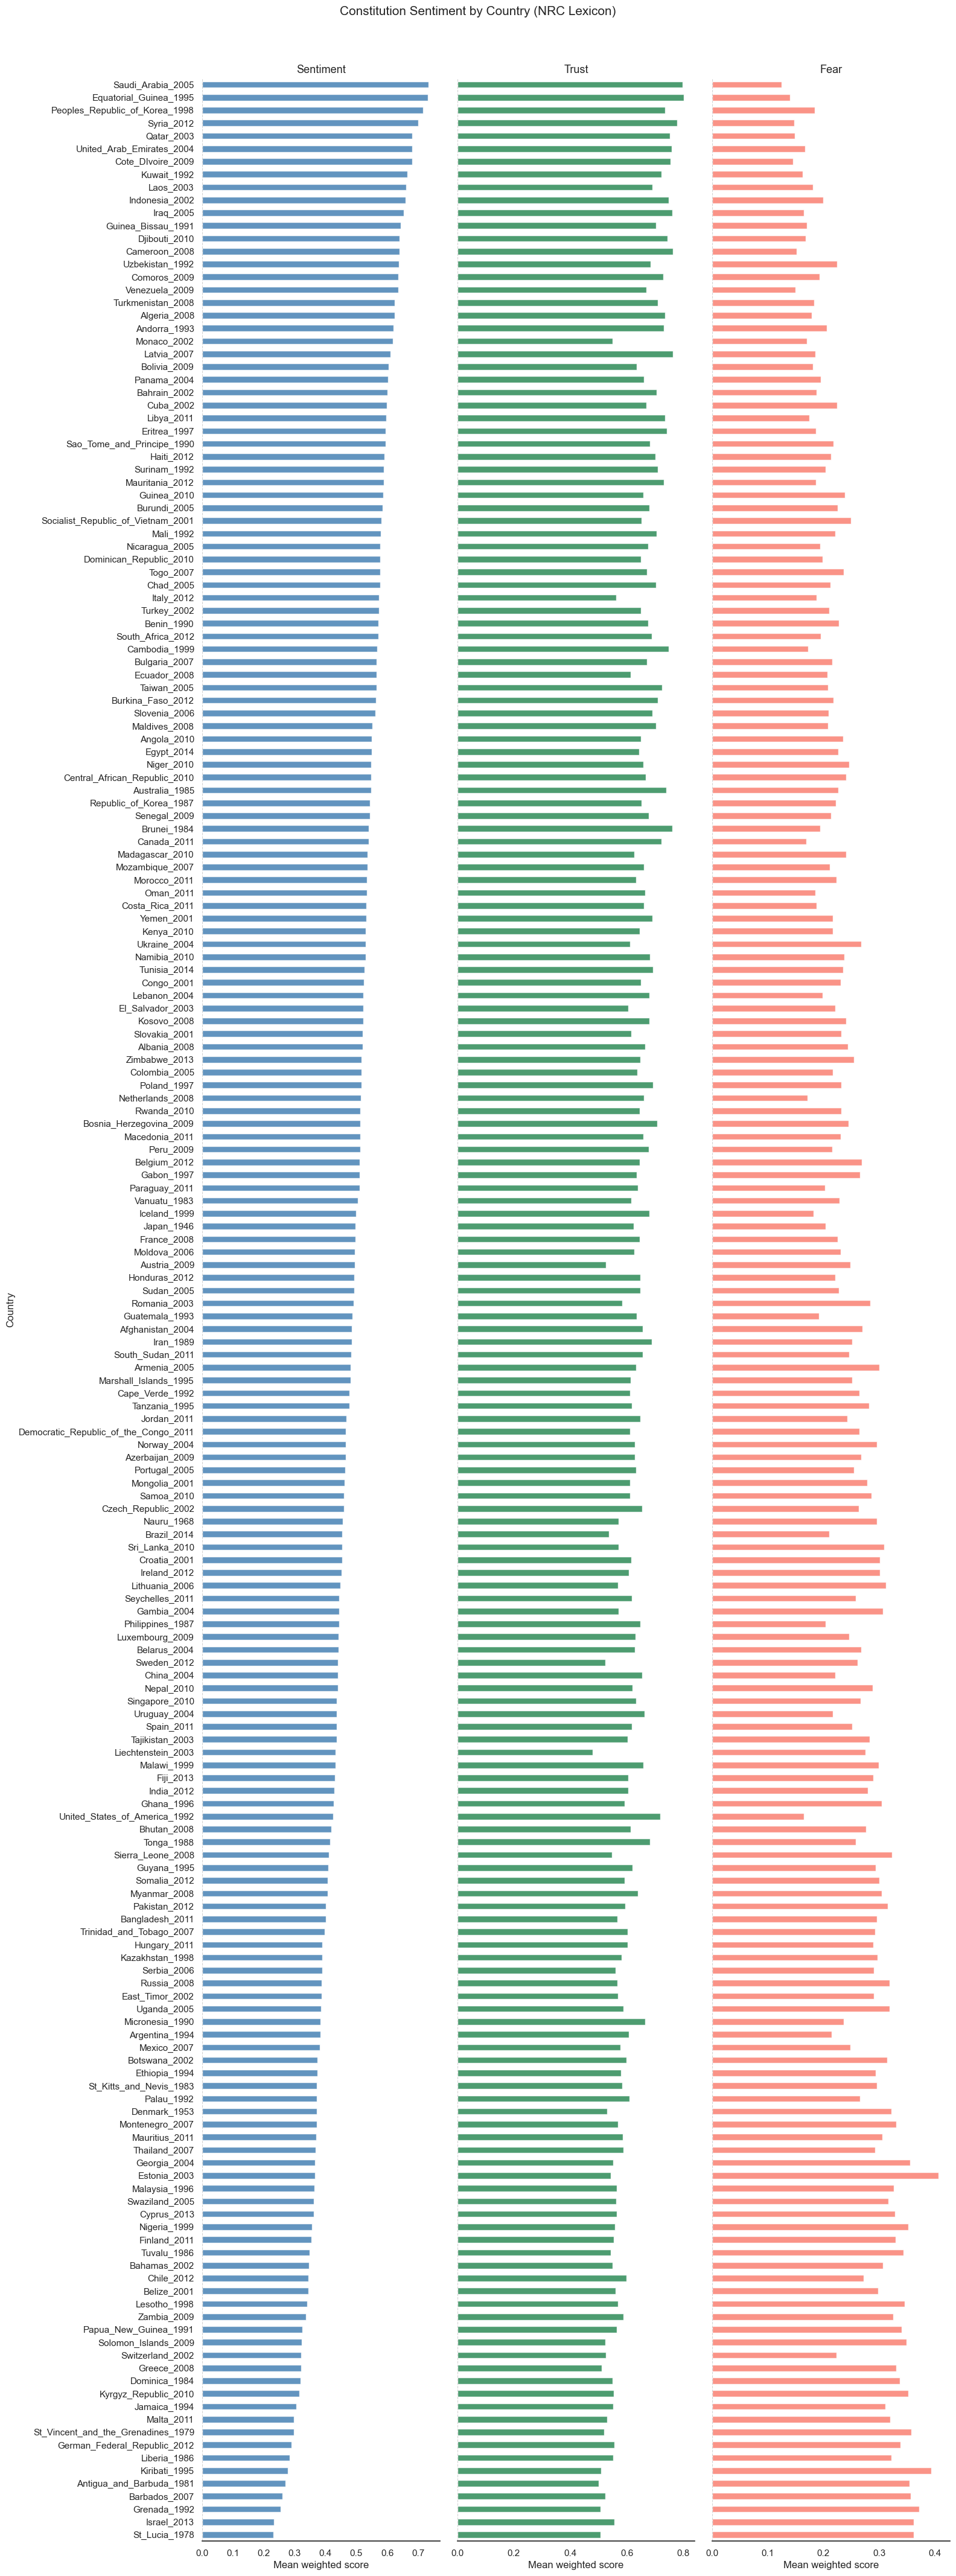

Plot saved.


In [11]:
plot_df = DOC_SENT[['sentiment', 'trust', 'fear']].sort_values('sentiment')

fig, axes = plt.subplots(1, 3, figsize=(16, max(6, len(plot_df) * 0.22)), sharey=True)

for ax, col, color in zip(axes, ['sentiment', 'trust', 'fear'], ['steelblue', 'seagreen', 'salmon']):
    plot_df[col].plot.barh(ax=ax, color=color, alpha=0.85)
    ax.axvline(0, color='lightgray', ls='--', lw=0.8)
    ax.set_title(col.capitalize(), fontsize=13)
    ax.set_xlabel('Mean weighted score')
    sns.despine(ax=ax, left=True)

fig_dir = 'figures'
axes[0].set_ylabel('Country')
plt.suptitle('Constitution Sentiment by Country (NRC Lexicon)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f'{fig_dir}/const_sentiment_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

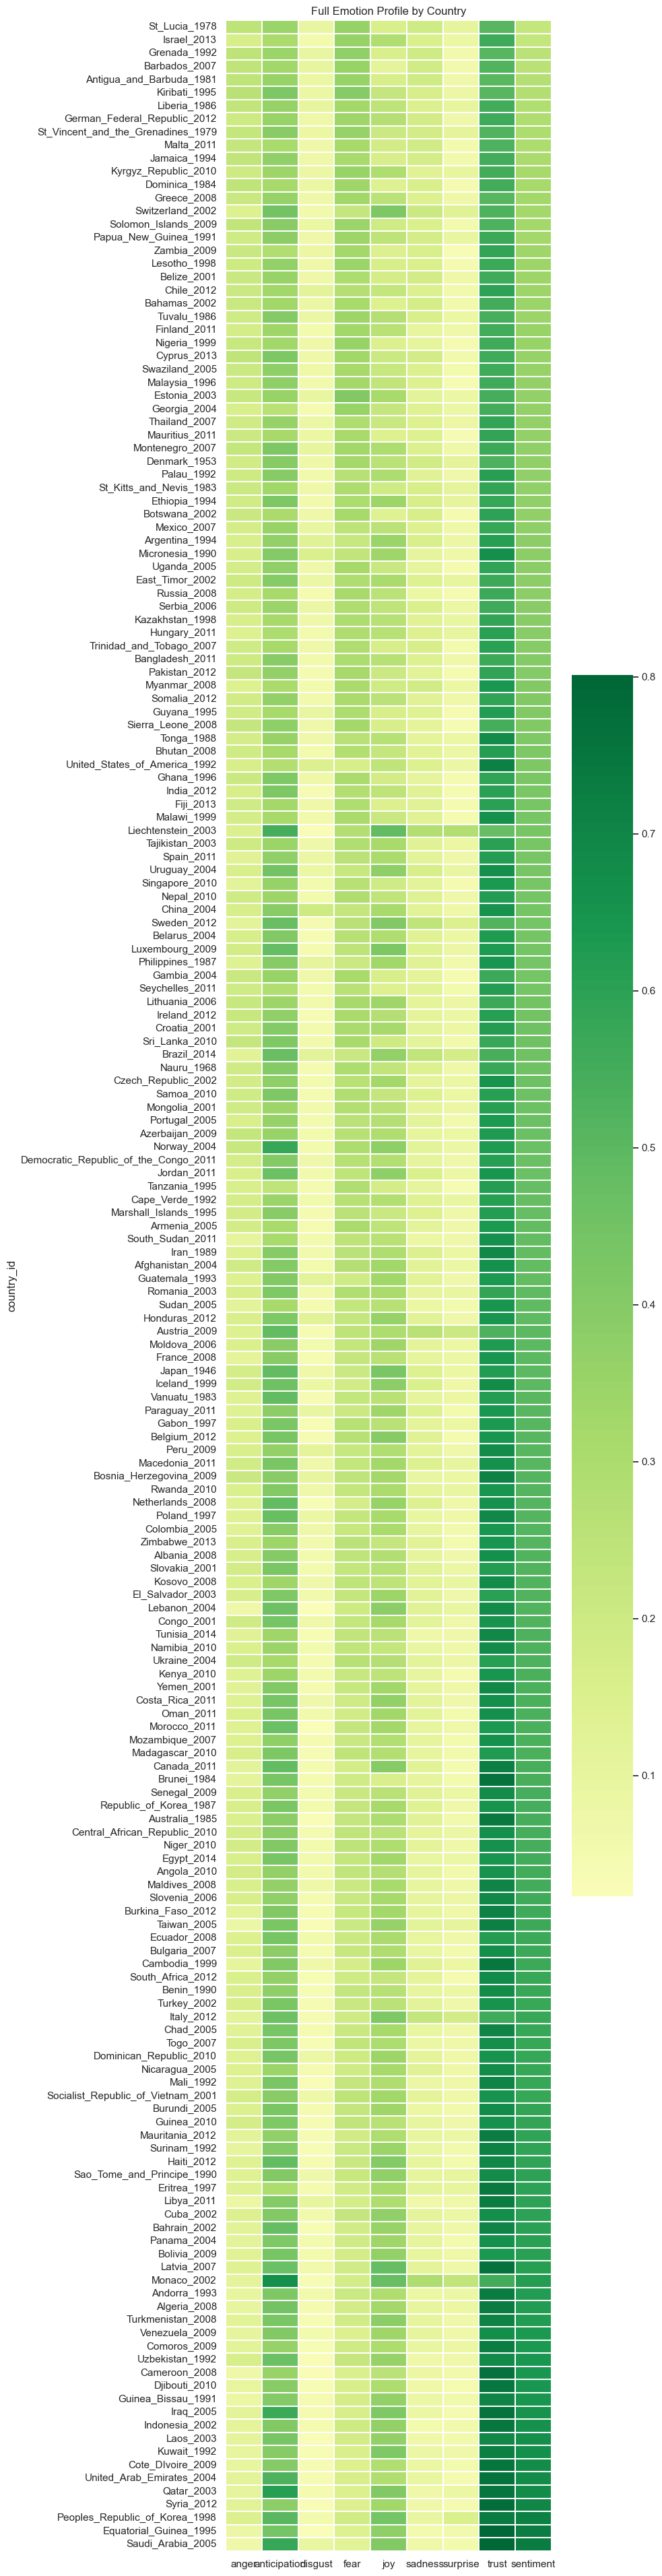

In [12]:
fig, ax = plt.subplots(figsize=(10, max(6, len(DOC_SENT) * 0.2)))
sns.heatmap(
    DOC_SENT[emo_cols].sort_values('sentiment'),
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.3, linecolor='white'
)
ax.set_title('Full Emotion Profile by Country')
plt.tight_layout()
plt.savefig(f'{fig_dir}/const_sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()